# Machine Clustering Based on Sensor & Defect Metrics
Cluster **MachineID** by their average operating characteristics:
- DefectRate  (DefectCount / ProductionUnits)
- Vibration
- Temperature
- Pressure

Each cluster is then labelled descriptively (e.g. *High Defect / High Vibration*).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

## 1. Load Data

In [2]:
df = pd.read_csv('QUALITY & DEFECT REDUCTION.csv')
print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')
df.head()

Rows: 20,000  |  Columns: 10


,Timestamp,MachineID,Plant,Temperature,Vibration,Pressure,EnergyConsumption,ProductionUnits,DefectCount,MaintenanceFlag
0,2025-01-01 00:00:00,142,Plant_B,77.474270,2.604480,23.438160,315.443998,52,4,0
1,2025-01-01 01:00:00,124,Plant_C,72.435288,6.240213,30.236166,300.579876,89,1,0
2,2025-01-01 02:00:00,103,Plant_A,59.063863,6.470758,32.778778,240.961506,194,0,0
3,2025-01-01 03:00:00,108,Plant_C,63.859148,3.646682,26.077120,206.954154,190,2,0
4,2025-01-01 04:00:00,100,Plant_B,76.799275,5.261242,33.432417,259.130150,173,8,1


## 2. Feature Engineering – Compute DefectRate

In [3]:
# DefectRate = DefectCount / ProductionUnits
df['DefectRate'] = df['DefectCount'] / df['ProductionUnits']
df[['MachineID', 'DefectCount', 'ProductionUnits', 'DefectRate']].head(10)

,MachineID,DefectCount,ProductionUnits,DefectRate
0,142,4,52,0.076923
1,124,1,89,0.011236
2,103,0,194,0.000000
3,108,2,190,0.010526
4,100,8,173,0.046243
5,121,1,65,0.015385
6,119,2,55,0.036364
7,110,2,136,0.014706
8,143,2,180,0.011111
9,141,6,113,0.053097


## 3. Aggregate by MachineID (Mean Values)

In [4]:
# Group by MachineID and compute mean of the 4 clustering features
cluster_features = ['DefectRate', 'Vibration', 'Temperature', 'Pressure']

machine_agg = df.groupby('MachineID')[cluster_features].mean().reset_index()
machine_agg.columns = ['MachineID', 'mean_DefectRate', 'mean_Vibration',
                        'mean_Temperature', 'mean_Pressure']
print(f'Number of unique machines: {machine_agg.shape[0]}')
machine_agg.head(10)

Number of unique machines: 50


,MachineID,mean_DefectRate,mean_Vibration,mean_Temperature,mean_Pressure
0,100,0.028896,5.119509,69.729144,30.550820
1,101,0.027600,4.937900,70.082934,30.169352
2,102,0.026264,4.948084,69.981160,29.947623
3,103,0.027602,5.048506,70.219775,30.119664
4,104,0.028507,5.023351,69.679257,29.725638
5,105,0.026990,5.077539,69.620218,29.823627
6,106,0.026722,5.070701,70.921383,30.025610
7,107,0.027024,4.944535,70.501882,29.704255
8,108,0.027017,5.072418,70.182803,30.134755
9,109,0.028452,4.872794,70.858553,29.919374


## 4. Standardize Features

In [5]:
feature_cols = ['mean_DefectRate', 'mean_Vibration', 'mean_Temperature', 'mean_Pressure']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(machine_agg[feature_cols])
print('Scaled feature matrix shape:', X_scaled.shape)

Scaled feature matrix shape: (50, 4)


## 5. Optimal K – Elbow Method

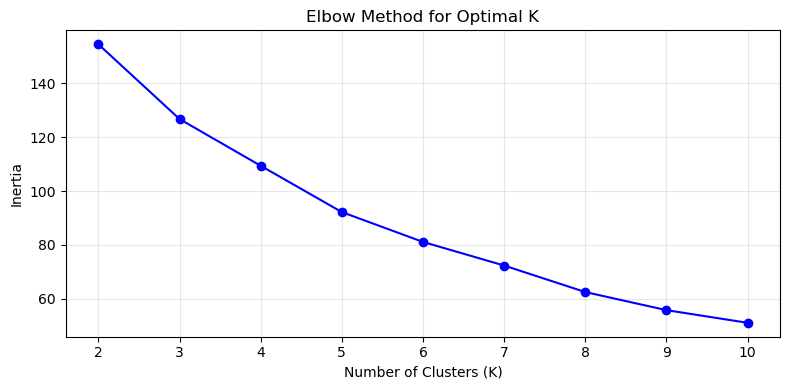

In [6]:
inertias = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.xticks(list(K_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Fit KMeans (K = 4)

In [7]:
K = 4
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
machine_agg['Cluster'] = kmeans.fit_predict(X_scaled)
print(f'Cluster distribution:\n{machine_agg["Cluster"].value_counts().sort_index()}')

Cluster distribution:
Cluster
0    16
1     8
2    10
3    16
Name: count, dtype: int64


## 7. Label Clusters Descriptively
Labels are based on whether the cluster centroid is **above** or **below** the overall mean for DefectRate and Vibration.

In [8]:
# Compute cluster centroids in original scale
centroids_scaled = kmeans.cluster_centers_
centroids = scaler.inverse_transform(centroids_scaled)
centroid_df = pd.DataFrame(centroids, columns=feature_cols)
centroid_df.index.name = 'Cluster'

# Overall means (thresholds)
overall_means = machine_agg[feature_cols].mean()

# Build descriptive labels
labels = {}
for cluster_id, row in centroid_df.iterrows():
    parts = []
    # DefectRate
    dr_level = 'High Defect' if row['mean_DefectRate'] >= overall_means['mean_DefectRate'] else 'Low Defect'
    parts.append(dr_level)
    # Vibration
    vib_level = 'High Vibration' if row['mean_Vibration'] >= overall_means['mean_Vibration'] else 'Low Vibration'
    parts.append(vib_level)
    # Temperature
    temp_level = 'High Temp' if row['mean_Temperature'] >= overall_means['mean_Temperature'] else 'Low Temp'
    parts.append(temp_level)
    # Pressure
    pres_level = 'High Pressure' if row['mean_Pressure'] >= overall_means['mean_Pressure'] else 'Low Pressure'
    parts.append(pres_level)
    labels[cluster_id] = ' / '.join(parts)

machine_agg['Cluster_Label'] = machine_agg['Cluster'].map(labels)

print('Cluster Labels:')
for k, v in labels.items():
    print(f'  Cluster {k}: {v}')

Cluster Labels:
  Cluster 0: High Defect / Low Vibration / High Temp / High Pressure
  Cluster 1: High Defect / Low Vibration / High Temp / Low Pressure
  Cluster 2: High Defect / High Vibration / Low Temp / Low Pressure
  Cluster 3: Low Defect / High Vibration / High Temp / High Pressure


## 8. Cluster Summary

In [9]:
# Summary table: mean of each feature per cluster + count of machines
summary = machine_agg.groupby(['Cluster', 'Cluster_Label'])[feature_cols].agg(['mean', 'std']).round(4)
summary.columns = ['_'.join(col) for col in summary.columns]

# Add machine count
counts = machine_agg.groupby(['Cluster', 'Cluster_Label']).size().rename('Machine_Count')
summary = summary.join(counts)

print('='*80)
print('CLUSTER SUMMARY')
print('='*80)
summary

CLUSTER SUMMARY


,,mean_DefectRate_mean,mean_DefectRate_std,mean_Vibration_mean,mean_Vibration_std,mean_Temperature_mean,mean_Temperature_std,mean_Pressure_mean,mean_Pressure_std,Machine_Count
Cluster,Cluster_Label,,,,,,,,,
0,High Defect / Low Vibration / High Temp / High Pressure,0.0282,0.0006,4.9612,0.0550,70.1261,0.4097,30.1320,0.1622,16
1,High Defect / Low Vibration / High Temp / Low Pressure,0.0285,0.0008,4.9401,0.0562,70.5598,0.4000,29.6669,0.2303,8
2,High Defect / High Vibration / Low Temp / Low Pressure,0.0283,0.0006,5.0275,0.0582,69.5138,0.3033,29.9526,0.2589,10
3,Low Defect / High Vibration / High Temp / High Pressure,0.0269,0.0004,5.0470,0.0489,70.1061,0.3162,29.9724,0.1918,16


## 9. Machines in Each Cluster

In [10]:
for label in machine_agg['Cluster_Label'].unique():
    machines = machine_agg.loc[machine_agg['Cluster_Label'] == label, 'MachineID'].tolist()
    print(f'\n{label}')
    print(f'  Machines ({len(machines)}): {machines}')


High Defect / High Vibration / Low Temp / Low Pressure
  Machines (10): [100, 104, 115, 119, 122, 123, 128, 130, 141, 147]

High Defect / Low Vibration / High Temp / High Pressure
  Machines (16): [101, 110, 112, 113, 114, 120, 121, 126, 127, 129, 134, 137, 138, 140, 142, 146]

Low Defect / High Vibration / High Temp / High Pressure
  Machines (16): [102, 103, 105, 106, 108, 116, 124, 132, 133, 135, 136, 143, 144, 145, 148, 149]

High Defect / Low Vibration / High Temp / Low Pressure
  Machines (8): [107, 109, 111, 117, 118, 125, 131, 139]


## 10. Scatter Plot – DefectRate vs Vibration by Cluster

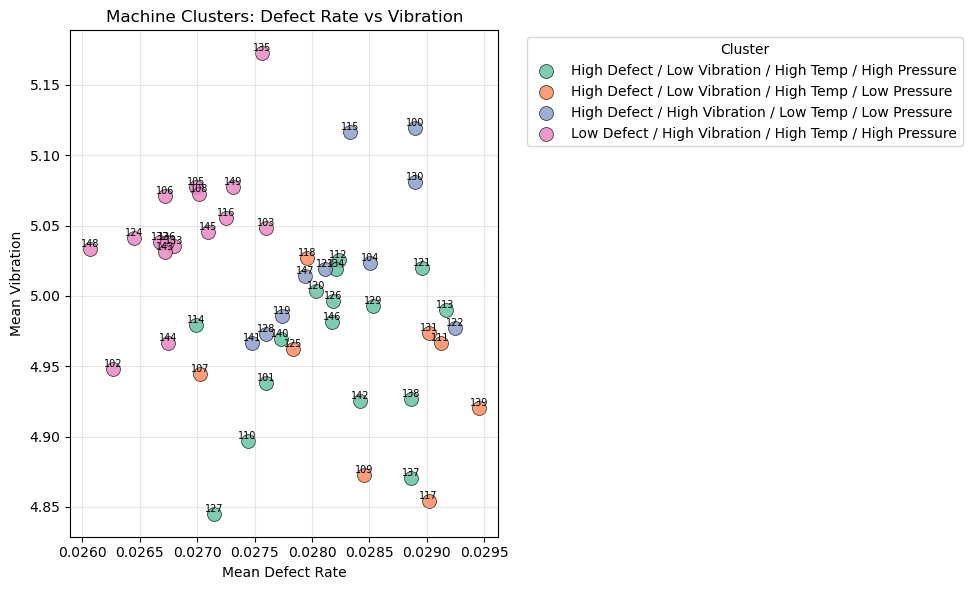

In [11]:
plt.figure(figsize=(10, 6))
palette = sns.color_palette('Set2', n_colors=K)

for i, label in labels.items():
    subset = machine_agg[machine_agg['Cluster'] == i]
    plt.scatter(subset['mean_DefectRate'], subset['mean_Vibration'],
                label=label, s=100, edgecolors='k', linewidth=0.5,
                color=palette[i], alpha=0.85)
    for _, row in subset.iterrows():
        plt.annotate(int(row['MachineID']),
                     (row['mean_DefectRate'], row['mean_Vibration']),
                     fontsize=7, ha='center', va='bottom')

plt.xlabel('Mean Defect Rate')
plt.ylabel('Mean Vibration')
plt.title('Machine Clusters: Defect Rate vs Vibration')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Heatmap of Cluster Centroids

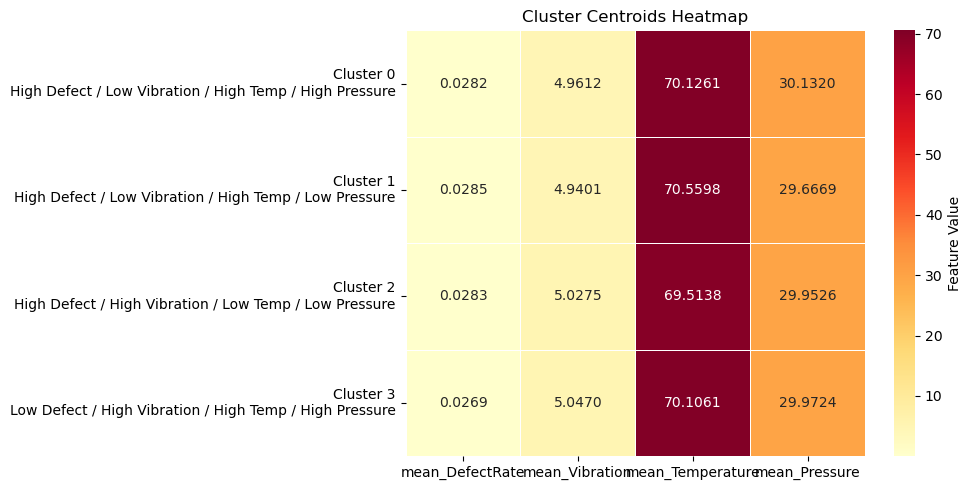

In [12]:
centroid_display = centroid_df.copy()
centroid_display.index = [f'Cluster {i}\n{labels[i]}' for i in centroid_display.index]

plt.figure(figsize=(10, 5))
sns.heatmap(centroid_display, annot=True, fmt='.4f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Feature Value'})
plt.title('Cluster Centroids Heatmap')
plt.tight_layout()
plt.show()

## 12. Full Machine–Cluster Assignment Table

In [13]:
output = machine_agg[['MachineID', 'mean_DefectRate', 'mean_Vibration',
                       'mean_Temperature', 'mean_Pressure',
                       'Cluster', 'Cluster_Label']].sort_values('MachineID')
output

,MachineID,mean_DefectRate,mean_Vibration,mean_Temperature,mean_Pressure,Cluster,Cluster_Label
0,100,0.028896,5.119509,69.729144,30.550820,2,High Defect / High Vibration / Low Temp / Low ...
1,101,0.027600,4.937900,70.082934,30.169352,0,High Defect / Low Vibration / High Temp / High...
2,102,0.026264,4.948084,69.981160,29.947623,3,Low Defect / High Vibration / High Temp / High...
3,103,0.027602,5.048506,70.219775,30.119664,3,Low Defect / High Vibration / High Temp / High...
4,104,0.028507,5.023351,69.679257,29.725638,2,High Defect / High Vibration / Low Temp / Low ...
5,105,0.026990,5.077539,69.620218,29.823627,3,Low Defect / High Vibration / High Temp / High...
6,106,0.026722,5.070701,70.921383,30.025610,3,Low Defect / High Vibration / High Temp / High...
7,107,0.027024,4.944535,70.501882,29.704255,1,High Defect / Low Vibration / High Temp / Low ...
8,108,0.027017,5.072418,70.182803,30.134755,3,Low Defect / High Vibration / High Temp / High...
9,109,0.028452,4.872794,70.858553,29.919374,1,High Defect / Low Vibration / High Temp / Low ...
